### AI-Powered Climate-Smart Farmer Advisory Systems

### Domain: Climate Risk Prediction

Climate risk prediction is the systematic process of identifying, quantifying, and forecasting the financial, physical, and operational vulnerabilities triggered by climate change. It leverages multi-model climate ensembles, machine learning, and historical records to map future probability distributions of extreme weather and slow-onset hazards

### Problem Statement

the agricultural sector reacts to climate disasters—like droughts, floods, and unseasonal frosts—only after the damage is done. This reactive approach devastates crop yields and disrupts food supply chains. The core problem is a lack of predictive foresight. Farmers, governments, insurers, and agri-businesses need the ability to anticipate climate-related agricultural risks before they strike. This foresight is critical to shift from costly damage control to proactive prevention.

### Goal

AI-driven early warning system capable of anticipating adverse weather and localized climate risks. By continuously analyzing complex meteorological data, the system will generate hyper-local, real-time alerts. This predictive intelligence aims to empower farmers with actionable foresight, granting them the crucial lead time needed to implement preventive measures, safeguard their crops, and avoid devastating financial losses before a disaster strikes.

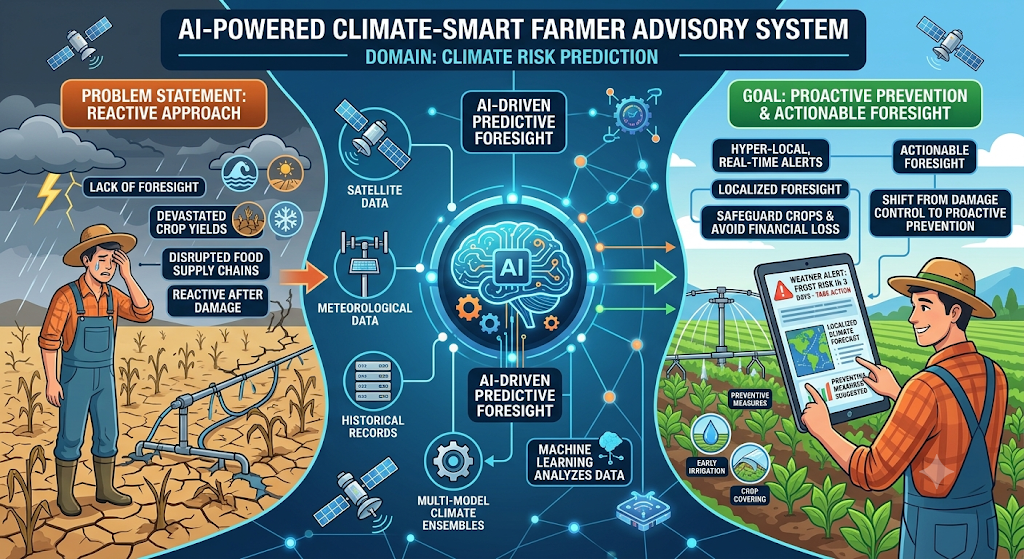


## Data Collection
###  Dataset Source Link : https://open-meteo.com/en/docs/historical-weather-api

Open-Meteo Historical Weather API is the foundational dataset for training our AI models. It provides decades of high-resolution, hyper-local meteorological data, including critical variables like temperature, precipitation, soil moisture, and solar radiation. By analyzing these historical weather patterns and past climate anomalies, our machine learning algorithms learn to identify early warning signs of extreme weather, enabling the system to generate highly accurate future risk predictions.

### Import Libraries

##### pandas → pandas → Used for loading, cleaning, organizing, and manipulating tabular data (DataFrames).
##### numpy → Used for numerical operations, mathematical calculations, and working with arrays.
##### Matplotlib → Used for creating basic data visualizations such as line charts, bar charts, histograms, and scatter plots.
##### Seaborn → Used for creating attractive statistical visualizations such as heatmaps, box plots, count plots, and distribution plots.
##### warnings → Used for handling and controlling warning messages generated during program execution Ignore that Information.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Connect to Database

In [2]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

url = URL.create(
    "mysql+pymysql",
    username="root",
    password="manojA@61",
    host="localhost",
    port=3306,
    database="climate_risk_db")
engine = create_engine(url)

In [3]:
try:
    with engine.connect() as conn:
        print("Connected successfully!")
except Exception as e:
    print(e)

Connected successfully!


### Load Dataset

To handle all one datasets efficiently, we load them into a dictionary
historical climate records, the system establishes a connection to the climate_risk_db MySQL database using the SQLAlchemy and PyMySQL libraries. By securely constructing the connection string via URL.create, we keep configuration structured. Once connected, pandas.read_sql executes a query to load the weather_dataset table directly into a DataFrame. This efficiently structures the raw meteorological data, prepping it for downstream AI model training.

In [4]:
df = pd.read_sql("SELECT * FROM weather_dataset",engine)
df.head()

,Date,Time,city,state,latitude,longitude,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,...,Sand,Silt,Elevation,Heat_Index,Rainfall_Last_7_Days,Rainfall_Last_30_Days,Consecutive_Dry_Days,Growing_Degree_Days,Climate_Risk,Crop
0,01-01-2024,0.00.00,Adilabad,Telangana,19.6641,78.532,18.4,80,0.0,983.7,...,42,30,100,26.4,0.0,0.0,1,8.4,Low,Karbuja(Musk Melon)
1,01-01-2024,1.00.00,Adilabad,Telangana,19.6641,78.532,17.8,79,0.0,983.5,...,42,30,100,25.7,0.0,0.0,2,7.8,Low,Karbuja(Musk Melon)
2,01-01-2024,2.00.00,Adilabad,Telangana,19.6641,78.532,17.6,77,0.0,983.3,...,42,30,100,25.3,0.0,0.0,3,7.6,Low,Karbuja(Musk Melon)
3,01-01-2024,3.00.00,Adilabad,Telangana,19.6641,78.532,16.9,78,0.0,983.0,...,42,30,100,24.7,0.0,0.0,4,6.9,Low,Karbuja(Musk Melon)
4,01-01-2024,4.00.00,Adilabad,Telangana,19.6641,78.532,16.8,79,0.0,983.3,...,42,30,100,24.7,0.0,0.0,5,6.8,Low,Karbuja(Musk Melon)


#### Basic Information

Shape means verifies the loaded climate dataset's size via row and column counts.

In [5]:
print(df.shape)

(1048575, 32)


Identifies the data type of each column, ensuring climate features are ML-ready.

In [6]:
print(df.dtypes)

Date                           object
Time                           object
city                           object
state                          object
latitude                      float64
longitude                     float64
temperature_2m                float64
relative_humidity_2m            int64
precipitation                 float64
surface_pressure              float64
cloud_cover                     int64
wind_speed_10m                float64
wind_direction_10m              int64
wind_gusts_10m                float64
shortwave_radiation             int64
et0_fao_evapotranspiration    float64
Season                         object
Soil_Moisture                 float64
Soil_Temperature              float64
Soil_pH                       float64
Organic_Carbon                float64
Clay                            int64
Sand                            int64
Silt                            int64
Elevation                       int64
Heat_Index                    float64
Rainfall_Las

#### Use Case of column name

| Column Name                | Data Type         | Purpose / Use Case in the AI Model                                                                                                    |
| -------------------------- | ----------------- | ------------------------------------------------------------------------------------------------------------------------------------- |
| Date                       | datetime64        | Tracks the observation date. Essential for time-series forecasting, trend analysis, and seasonal pattern detection.                   |
| Time                       | object / datetime | Records the time of observation. Helps analyze diurnal (day–night) weather variations affecting crops.                                |
| City                       | object            | Geographic identifier used for location-wise climate analysis and regional risk prediction.                                           |
| State                      | object            | Administrative region used for state-level climate monitoring and policy recommendations.                                             |
| Latitude                   | float64           | Geographic coordinate used for precise spatial mapping and integration with satellite or GIS data.                                    |
| Longitude                  | float64           | Geographic coordinate used for location-specific climate forecasting and weather station mapping.                                     |
| Temperature_2m             | float64           | Air temperature at 2 meters above ground. Critical for detecting heat stress, frost, and crop development stages.                     |
| Relative_Humidity_2m       | float64           | Measures atmospheric moisture. Combined with temperature to predict disease outbreaks and crop stress.                                |
| Precipitation              | float64           | Amount of rainfall received. Major factor in drought, flood, and irrigation requirement prediction.                                   |
| Surface_Pressure           | float64           | Atmospheric pressure used to detect storms, cyclones, and changing weather systems.                                                   |
| Cloud_Cover                | float64           | Percentage of cloud coverage. Influences solar radiation, evaporation, and daily temperature changes.                                 |
| Wind_Speed_10m             | float64           | Wind speed measured at 10 meters. Used to estimate crop lodging, evaporation, and soil erosion risk.                                  |
| Wind_Direction_10m         | float64           | Wind direction used to predict movement of pests, diseases, smoke, and weather fronts.                                                |
| Wind_Gusts_10m             | float64           | Maximum wind bursts. Important for forecasting severe weather damage to crops and infrastructure.                                     |
| Shortwave_Radiation        | float64           | Incoming solar energy. Essential for photosynthesis estimation and crop growth modeling.                                              |
| ET0_FAO_Evapotranspiration | float64           | Reference evapotranspiration. Standard indicator for irrigation planning and crop water demand estimation.                            |
| Season                     | object            | Agricultural season (Kharif, Rabi, Summer, etc.). Helps the model account for seasonal crop patterns.                                 |
| Soil_Moisture              | float64           | Soil water content. Direct indicator of drought stress and waterlogging conditions.                                                   |
| Soil_Temperature           | float64           | Soil heat level affecting seed germination, root growth, and microbial activity.                                                      |
| Soil_pH                    | float64           | Soil acidity/alkalinity. Determines nutrient availability and crop suitability.                                                       |
| Organic_Carbon             | float64           | Indicates soil fertility and water retention capacity. Higher values improve climate resilience.                                      |
| Clay                       | float64           | Percentage of clay particles. Influences drainage, water retention, and flood susceptibility.                                         |
| Sand                       | float64           | Percentage of sand particles. Affects drainage speed and drought vulnerability.                                                       |
| Silt                       | float64           | Percentage of silt particles. Impacts soil fertility and moisture-holding capacity.                                                   |
| Elevation                  | float64           | Height above sea level. Influences temperature, rainfall distribution, and microclimates.                                             |
| Heat_Index                 | float64           | "Feels-like" temperature calculated from temperature and humidity. Used for heat stress assessment.                                   |
| Rainfall_Last_7_Days       | float64           | Cumulative rainfall over the past week. Indicates recent soil saturation and flood potential.                                         |
| Rainfall_Last_30_Days      | float64           | Monthly accumulated rainfall. Useful for identifying long-term drought or excessive rainfall trends.                                  |
| Consecutive_Dry_Days       | int64             | Number of continuous days without rainfall. Strong indicator of drought severity.                                                     |
| Growing_Degree_Days (GDD)  | float64           | Accumulated heat units used to estimate crop growth stages and harvest timing.                                                        |
| Crop                       | object            | Crop type (Rice, Cotton, Maize, etc.). Enables crop-specific climate risk prediction.                                                 |
| Climate_Risk               | object (Target)   | **Target variable** containing labels such as Low, Medium, High or Drought, Flood, Frost, Normal. Used to train the prediction model. |


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 32 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Date                        1048575 non-null  object 
 1   Time                        1048575 non-null  object 
 2   city                        1048575 non-null  object 
 3   state                       1048575 non-null  object 
 4   latitude                    1048575 non-null  float64
 5   longitude                   1048575 non-null  float64
 6   temperature_2m              1048575 non-null  float64
 7   relative_humidity_2m        1048575 non-null  int64  
 8   precipitation               1048575 non-null  float64
 9   surface_pressure            1048575 non-null  float64
 10  cloud_cover                 1048575 non-null  int64  
 11  wind_speed_10m              1048575 non-null  float64
 12  wind_direction_10m          1048575 non-null  int64  
 1

insights : highly structured dataset containing over 1 million records (1,048,575 rows) and 32 critical climate features. Crucially, there are zero missing values across the entire dataset, meaning the data is remarkably clean and requires no immediate imputation.Featuring 25 numerical columns for precise meteorological calculations and 7 categorical columns for geographic and crop context, this 256 MB dataset is perfectly primed for training our AI models.

### Data Validation

| Validation        | Purpose                          | Python Function              |
| ----------------- | -------------------------------- | ---------------------------- |
| Missing Values    | Check null values                | `isnull()`                   |
| Duplicate Records | Find duplicate rows              | `duplicated()`               |
| Data Types        | Verify correct data types        | `dtypes`, `info()`           |
| Range Validation  | Check values within valid limits | Boolean conditions           |
| Unique Values     | Check categorical values         | `unique()`, `value_counts()` |
| Outlier Detection | Detect abnormal values           | IQR, Z-score                 |
| Date Validation   | Check date format                | `pd.to_datetime()`           |
| Infinite Values   | Detect ±∞                        | `np.isinf()`                 |
| Negative Values   | Check impossible negatives       | Comparison operators         |
| Consistency Check | Ensure logical relationships     | Conditional statements       |


creates a safe, independent backup of our climate data before preprocessing.

In [8]:
df1 = df.copy()

In [9]:
print("Shape:", df1.shape)

Shape: (1048575, 32)


##### Object convert into lowercase

Converting all string columns to lowercase prevents the AI from treating text variations (like "Crop" vs. "crop") as separate categories, ensuring clean data for model training.

In [10]:
# Convert all object (string) columns to lowercase
object_cols = df1.select_dtypes(include="object").columns
df1[object_cols] = df1[object_cols].apply(lambda col: col.str.lower())
print("All object columns have been converted to lowercase!")

All object columns have been converted to lowercase!


##### Displays the first 5 rows to verify the data loaded correctly

In [11]:
# Print the head of the dataframe
df1.head(5)

,Date,Time,city,state,latitude,longitude,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,...,Sand,Silt,Elevation,Heat_Index,Rainfall_Last_7_Days,Rainfall_Last_30_Days,Consecutive_Dry_Days,Growing_Degree_Days,Climate_Risk,Crop
0,01-01-2024,0.00.00,adilabad,telangana,19.6641,78.532,18.4,80,0.0,983.7,...,42,30,100,26.4,0.0,0.0,1,8.4,low,karbuja(musk melon)
1,01-01-2024,1.00.00,adilabad,telangana,19.6641,78.532,17.8,79,0.0,983.5,...,42,30,100,25.7,0.0,0.0,2,7.8,low,karbuja(musk melon)
2,01-01-2024,2.00.00,adilabad,telangana,19.6641,78.532,17.6,77,0.0,983.3,...,42,30,100,25.3,0.0,0.0,3,7.6,low,karbuja(musk melon)
3,01-01-2024,3.00.00,adilabad,telangana,19.6641,78.532,16.9,78,0.0,983.0,...,42,30,100,24.7,0.0,0.0,4,6.9,low,karbuja(musk melon)
4,01-01-2024,4.00.00,adilabad,telangana,19.6641,78.532,16.8,79,0.0,983.3,...,42,30,100,24.7,0.0,0.0,5,6.8,low,karbuja(musk melon)


#### Displays the last 5 rows to verify the data loaded correctly

In [12]:
# Print the last of the dataframe
print(df1.tail(5))
# Print the exact column names to help spot the KeyError
print(df1.columns.tolist())

               Date      Time    city           state  latitude  longitude  \
1048570  15-07-2026  19.00.00  y.s.r.  andhra pradesh   14.4673    78.8242   
1048571  15-07-2026  20.00.00  y.s.r.  andhra pradesh   14.4673    78.8242   
1048572  15-07-2026  21.00.00  y.s.r.  andhra pradesh   14.4673    78.8242   
1048573  15-07-2026  22.00.00  y.s.r.  andhra pradesh   14.4673    78.8242   
1048574  15-07-2026  23.00.00  y.s.r.  andhra pradesh   14.4673    78.8242   

         temperature_2m  relative_humidity_2m  precipitation  \
1048570            34.5                    25            0.0   
1048571            33.6                    28            0.0   
1048572            32.8                    30            0.0   
1048573            32.7                    32            0.0   
1048574            32.3                    38            0.0   

         surface_pressure  ...  Sand  Silt  Elevation  Heat_Index  \
1048570             990.4  ...    42    30        100        37.0   
1048571 

#### Used to display the DataFrame structure, data types, non-null values, and memory usage

In [13]:
# Run .info() directly on the dataframe variable
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 32 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Date                        1048575 non-null  object 
 1   Time                        1048575 non-null  object 
 2   city                        1048575 non-null  object 
 3   state                       1048575 non-null  object 
 4   latitude                    1048575 non-null  float64
 5   longitude                   1048575 non-null  float64
 6   temperature_2m              1048575 non-null  float64
 7   relative_humidity_2m        1048575 non-null  int64  
 8   precipitation               1048575 non-null  float64
 9   surface_pressure            1048575 non-null  float64
 10  cloud_cover                 1048575 non-null  int64  
 11  wind_speed_10m              1048575 non-null  float64
 12  wind_direction_10m          1048575 non-null  int64  
 1

## Check Dataset Shape

#### Shows the number of rows and columns

In [14]:
# df is now the pandas DataFrame, so .shape will work perfectly!
print(df1.shape)

(1048575, 32)


## Check Data Types

#### Identifies the datatype of each column

In [15]:
print(df1.dtypes)

Date                           object
Time                           object
city                           object
state                          object
latitude                      float64
longitude                     float64
temperature_2m                float64
relative_humidity_2m            int64
precipitation                 float64
surface_pressure              float64
cloud_cover                     int64
wind_speed_10m                float64
wind_direction_10m              int64
wind_gusts_10m                float64
shortwave_radiation             int64
et0_fao_evapotranspiration    float64
Season                         object
Soil_Moisture                 float64
Soil_Temperature              float64
Soil_pH                       float64
Organic_Carbon                float64
Clay                            int64
Sand                            int64
Silt                            int64
Elevation                       int64
Heat_Index                    float64
Rainfall_Las

#### Convert Date Column

In [16]:
print(df1["Date"].dtype)

object


### Duplicate Row Values Check

In [17]:
duplicates = df1.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


### Validate Numeric Columns

all numeric columns (int64 and float64) from the DataFrame df1 and displays their descriptive statistics. The describe() function summarizes each numeric column by calculating the count, mean, standard deviation (std), minimum (min), 25th percentile, median (50%), 75th percentile, and maximum (max). These statistics help validate the data, identify unusual values, detect potential outliers, and understand the overall distribution before performing data preprocessing, analysis, or machine learning.

In [18]:
numeric_cols = df1.select_dtypes(include=["int64","float64"]).columns
print(df1[numeric_cols].describe())

           latitude     longitude  temperature_2m  relative_humidity_2m  \
count  1.048575e+06  1.048575e+06    1.048575e+06          1.048575e+06   
mean   1.695715e+01  7.989299e+01    2.759317e+01          6.613205e+01   
std    1.535826e+00  1.724948e+00    4.804281e+00          2.124543e+01   
min    1.321720e+01  7.749540e+01    1.080000e+01          6.000000e+00   
25%    1.618750e+01  7.848360e+01    2.450000e+01          5.000000e+01   
50%    1.705750e+01  7.946370e+01    2.740000e+01          6.800000e+01   
75%    1.810670e+01  8.109520e+01    3.060000e+01          8.400000e+01   
max    1.966410e+01  8.389380e+01    4.650000e+01          1.000000e+02   

       precipitation  surface_pressure   cloud_cover  wind_speed_10m  \
count   1.048575e+06      1.048575e+06  1.048575e+06    1.048575e+06   
mean    1.286980e-01      9.853545e+02  5.490381e+01    9.584424e+00   
std     7.265189e-01      1.855500e+01  4.277415e+01    5.228584e+00   
min     0.000000e+00      9.361000e+

Insights: Stable soils mean weather drives yields. While 27.6°C averages favor growth, extreme risks—166-day dry spells, intense rain bursts, 102 km/h wind gusts, and heat stress—demand robust irrigation, drainage, and climate-focused forecasting to ensure agricultural success.

Check Numeric values Minimum and maximum

Check minimum and maximum values. It is used for range validation to verify that numeric data falls within expected limits and to identify invalid or unrealistic values, such as negative rainfall, impossible temperatures, or unusually large measurements. This helps detect data entry errors, outliers, and inconsistencies before data preprocessing, analysis, or machine learning, ensuring the dataset is reliable and suitable for accurate model training.

In [19]:
for col in numeric_cols:
    print(f"\n{col}")
    print("Minimum:", df1[col].min())
    print("Maximum:", df1[col].max())


latitude
Minimum: 13.2172
Maximum: 19.6641

longitude
Minimum: 77.4954
Maximum: 83.8938

temperature_2m
Minimum: 10.8
Maximum: 46.5

relative_humidity_2m
Minimum: 6
Maximum: 100

precipitation
Minimum: 0.0
Maximum: 54.1

surface_pressure
Minimum: 936.1
Maximum: 1020.1

cloud_cover
Minimum: 0
Maximum: 100

wind_speed_10m
Minimum: 0.0
Maximum: 51.5

wind_direction_10m
Minimum: 0
Maximum: 360

wind_gusts_10m
Minimum: 0.7
Maximum: 102.2

shortwave_radiation
Minimum: 0
Maximum: 1028

et0_fao_evapotranspiration
Minimum: 0.0
Maximum: 1.04

Soil_Moisture
Minimum: 0.22
Maximum: 0.45

Soil_Temperature
Minimum: 8.8
Maximum: 44.5

Soil_pH
Minimum: 6.8
Maximum: 7.2

Organic_Carbon
Minimum: 0.65
Maximum: 0.65

Clay
Minimum: 28
Maximum: 28

Sand
Minimum: 42
Maximum: 42

Silt
Minimum: 30
Maximum: 30

Elevation
Minimum: 30
Maximum: 384

Heat_Index
Minimum: 18.3
Maximum: 47.6

Rainfall_Last_7_Days
Minimum: 0.0
Maximum: 238.4

Rainfall_Last_30_Days
Minimum: 0.0
Maximum: 287.9

Consecutive_Dry_Days
Minim

Insights: severe climate extremes: scorching heat (46.5°C), cyclone-force gusts (102km/h), and massive rainfall swings over uniform, neutral-pH (6.8-7.2) loamy soils.

### Validate Categorical Columns

nunique values means every column how many unqiue value present show the number

In [20]:
categorical_cols = df1.select_dtypes(include="object").columns
for col in categorical_cols:
    print(f"\n{col}")
    print(df1[col].unique())


Date
['01-01-2024' '02-01-2024' '03-01-2024' '04-01-2024' '05-01-2024'
 '06-01-2024' '07-01-2024' '08-01-2024' '09-01-2024' '10-01-2024'
 '11-01-2024' '12-01-2024' '13-01-2024' '14-01-2024' '15-01-2024'
 '16-01-2024' '17-01-2024' '18-01-2024' '19-01-2024' '20-01-2024'
 '21-01-2024' '22-01-2024' '23-01-2024' '24-01-2024' '25-01-2024'
 '26-01-2024' '27-01-2024' '28-01-2024' '29-01-2024' '30-01-2024'
 '31-01-2024' '01-02-2024' '02-02-2024' '03-02-2024' '04-02-2024'
 '05-02-2024' '06-02-2024' '07-02-2024' '08-02-2024' '09-02-2024'
 '10-02-2024' '11-02-2024' '12-02-2024' '13-02-2024' '14-02-2024'
 '15-02-2024' '16-02-2024' '17-02-2024' '18-02-2024' '19-02-2024'
 '20-02-2024' '21-02-2024' '22-02-2024' '23-02-2024' '24-02-2024'
 '25-02-2024' '26-02-2024' '27-02-2024' '28-02-2024' '29-02-2024'
 '01-03-2024' '02-03-2024' '03-03-2024' '04-03-2024' '05-03-2024'
 '06-03-2024' '07-03-2024' '08-03-2024' '09-03-2024' '10-03-2024'
 '11-03-2024' '12-03-2024' '13-03-2024' '14-03-2024' '15-03-2024'
 '16

In [21]:
for col in categorical_cols:
    print(col, ":", df1[col].nunique())

Date : 927
Time : 24
city : 48
state : 2
Season : 4
Climate_Risk : 4
Crop : 14


#### Check Target Column
the distribution of our target variable, Climate_Risk. By counting the occurrences of each risk category (e.g., 'Low', 'moderate', 'high', 'extreme), we can instantly identify class imbalance.

In [22]:
print(df1["Climate_Risk"].value_counts())

Climate_Risk
low         988720
moderate     43347
high         14822
extreme       1686
Name: count, dtype: int64


normalize=True converts the frequency counts into proportions (percentages) instead of returning the raw number of occurrences.

In [23]:
print(df1["Climate_Risk"].value_counts(normalize=True)*100)

Climate_Risk
low         94.291777
moderate     4.133896
high         1.413537
extreme      0.160790
Name: proportion, dtype: float64


### Check Invalid Values

check the any Negative Rainfall

In [24]:
print((df1["precipitation"] < 0).sum())

0


Humidity >100

In [25]:
print((df1["relative_humidity_2m"] > 100).sum())

0


Latitude Range

In [26]:
print(((df1["latitude"] < -90) | (df1["latitude"] > 90)).sum())

0


Longitude Range

In [27]:
print(((df1["longitude"] < -180) | (df1["longitude"] > 180)).sum())

0



Check the Temeperature maximum and minimun

In [28]:
print(df1["temperature_2m"].min())
print(df1["temperature_2m"].max())

10.8
46.5


Insights: No negative values datasets columns are correct,precipitation(rainfall) = 0 no negative values,humidity = 0 no negative values,latitude and logitude no negative values is based on location and direction,temperature min = 10.8,temperature max = 46.5

Used to display the statistical summary of numerical columns in the DataFrame.

In [29]:
# Run .describe() on the actual dataframe 'df'
print(df1.describe())

           latitude     longitude  temperature_2m  relative_humidity_2m  \
count  1.048575e+06  1.048575e+06    1.048575e+06          1.048575e+06   
mean   1.695715e+01  7.989299e+01    2.759317e+01          6.613205e+01   
std    1.535826e+00  1.724948e+00    4.804281e+00          2.124543e+01   
min    1.321720e+01  7.749540e+01    1.080000e+01          6.000000e+00   
25%    1.618750e+01  7.848360e+01    2.450000e+01          5.000000e+01   
50%    1.705750e+01  7.946370e+01    2.740000e+01          6.800000e+01   
75%    1.810670e+01  8.109520e+01    3.060000e+01          8.400000e+01   
max    1.966410e+01  8.389380e+01    4.650000e+01          1.000000e+02   

       precipitation  surface_pressure   cloud_cover  wind_speed_10m  \
count   1.048575e+06      1.048575e+06  1.048575e+06    1.048575e+06   
mean    1.286980e-01      9.853545e+02  5.490381e+01    9.584424e+00   
std     7.265189e-01      1.855500e+01  4.277415e+01    5.228584e+00   
min     0.000000e+00      9.361000e+

In [30]:
print(df1.describe(include="object"))

              Date     Time      city           state   Season Climate_Risk  \
count      1048575  1048575   1048575         1048575  1048575      1048575   
unique         927       24        48               2        4            4   
top     01-01-2024  0.00.00  adilabad  andhra pradesh  monsoon          low   
freq          1152    43691     22248          556200   325992       988720   

           Crop  
count   1048575  
unique       14  
top      banana  
freq     186194  


In [31]:
print("Shape :", df1.shape)
print("Duplicate Rows :", df1.duplicated().sum())

Shape : (1048575, 32)
Duplicate Rows : 0


### Outlier Detection

In [32]:
import pandas as pd
cols = "temperature_2m relative_humidity_2m precipitation wind_speed_10m shortwave_radiation".split()
# Calculate stats for all columns at once
Q1, Q3 = df1[cols].quantile(0.25), df1[cols].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
# Count outliers
outliers = ((df1[cols] < lower) | (df1[cols] > upper)).sum()
# Combine into a clean summary table
summary = pd.DataFrame({'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'Lower': lower, 'Upper': upper, 'Outliers': outliers})
print(summary)

                        Q1     Q3    IQR   Lower    Upper  Outliers
temperature_2m        24.5   30.6    6.1   15.35    39.75     13549
relative_humidity_2m  50.0   84.0   34.0   -1.00   135.00         0
precipitation          0.0    0.0    0.0    0.00     0.00    151957
wind_speed_10m         5.6   12.9    7.3   -5.35    23.85     11405
shortwave_radiation    0.0  445.0  445.0 -667.50  1112.50         0


Insights: The IQR analysis shows that temperature_2m has 13,549 outliers, indicating periods of unusually high or low temperatures that may represent extreme weather events. Relative_humidity_2m and shortwave_radiation have no outliers, suggesting stable and consistent distributions. Precipitation has 151,957 outliers because most observations are zero, making rainfall events appear as outliers due to the highly skewed distribution. Wind_speed_10m has 11,405 outliers, reflecting occasional strong wind conditions. These results should be interpreted with domain knowledge before removing outliers.

### Exploratory Data Analysis (EDA)

Objectives
Understand the dataset structure
Study the distribution of each feature
Discover relationships between variables
Detect anomalies and outliers
Find the most important features influencing Climate_Risk

### Descriptive Statistics

Numerical Features

.T (Transpose): Flips the table. The original columns become the rows, and the statistical metrics become the columns.

In [33]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,1048575.0,16.957146,1.535826e+00,13.2172,16.1875,17.0575,18.1067,19.6641
longitude,1048575.0,79.892989,1.724948e+00,77.4954,78.4836,79.4637,81.0952,83.8938
temperature_2m,1048575.0,27.593173,4.804281e+00,10.8000,24.5000,27.4000,30.6000,46.5000
relative_humidity_2m,1048575.0,66.132047,2.124543e+01,6.0000,50.0000,68.0000,84.0000,100.0000
precipitation,1048575.0,0.128698,7.265189e-01,0.0000,0.0000,0.0000,0.0000,54.1000
surface_pressure,1048575.0,985.354496,1.855500e+01,936.1000,972.5000,987.7000,1001.0000,1020.1000
cloud_cover,1048575.0,54.903810,4.277415e+01,0.0000,6.0000,64.0000,100.0000,100.0000
wind_speed_10m,1048575.0,9.584424,5.228584e+00,0.0000,5.6000,8.8000,12.9000,51.5000
wind_direction_10m,1048575.0,187.078227,9.346741e+01,0.0000,111.0000,192.0000,265.0000,360.0000
wind_gusts_10m,1048575.0,21.207749,1.022880e+01,0.7000,13.3000,20.2000,27.7000,102.2000


Categorical Features

In [34]:
df1.describe(include="object").T

,count,unique,top,freq
Date,1048575,927,01-01-2024,1152
Time,1048575,24,0.00.00,43691
city,1048575,48,adilabad,22248
state,1048575,2,andhra pradesh,556200
Season,1048575,4,monsoon,325992
Climate_Risk,1048575,4,low,988720
Crop,1048575,14,banana,186194


### Target Variable Analysis

In [35]:
print(df1["Climate_Risk"].value_counts())

Climate_Risk
low         988720
moderate     43347
high         14822
extreme       1686
Name: count, dtype: int64


In [36]:
print(df1["Climate_Risk"].value_counts(normalize = True)*100)

Climate_Risk
low         94.291777
moderate     4.133896
high         1.413537
extreme      0.160790
Name: proportion, dtype: float64


#### Climate_risk Target value using countplot visualization

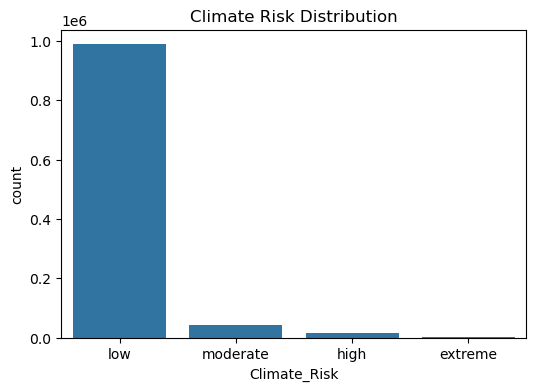

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=df1, x="Climate_Risk")
plt.title("Climate Risk Distribution")
plt.show()

##### Business Insights:
low climate risk domainates the dataset around 95+.
this dataset is highly imbalanced with very few moderate,high, and almost no extreme risk records
extreme category contains zero records.

### Univariate Analysis

Univariate analysis is the simplest form of statistical data analysis that examines only one variable at a time

Statistical Numerical Histograms

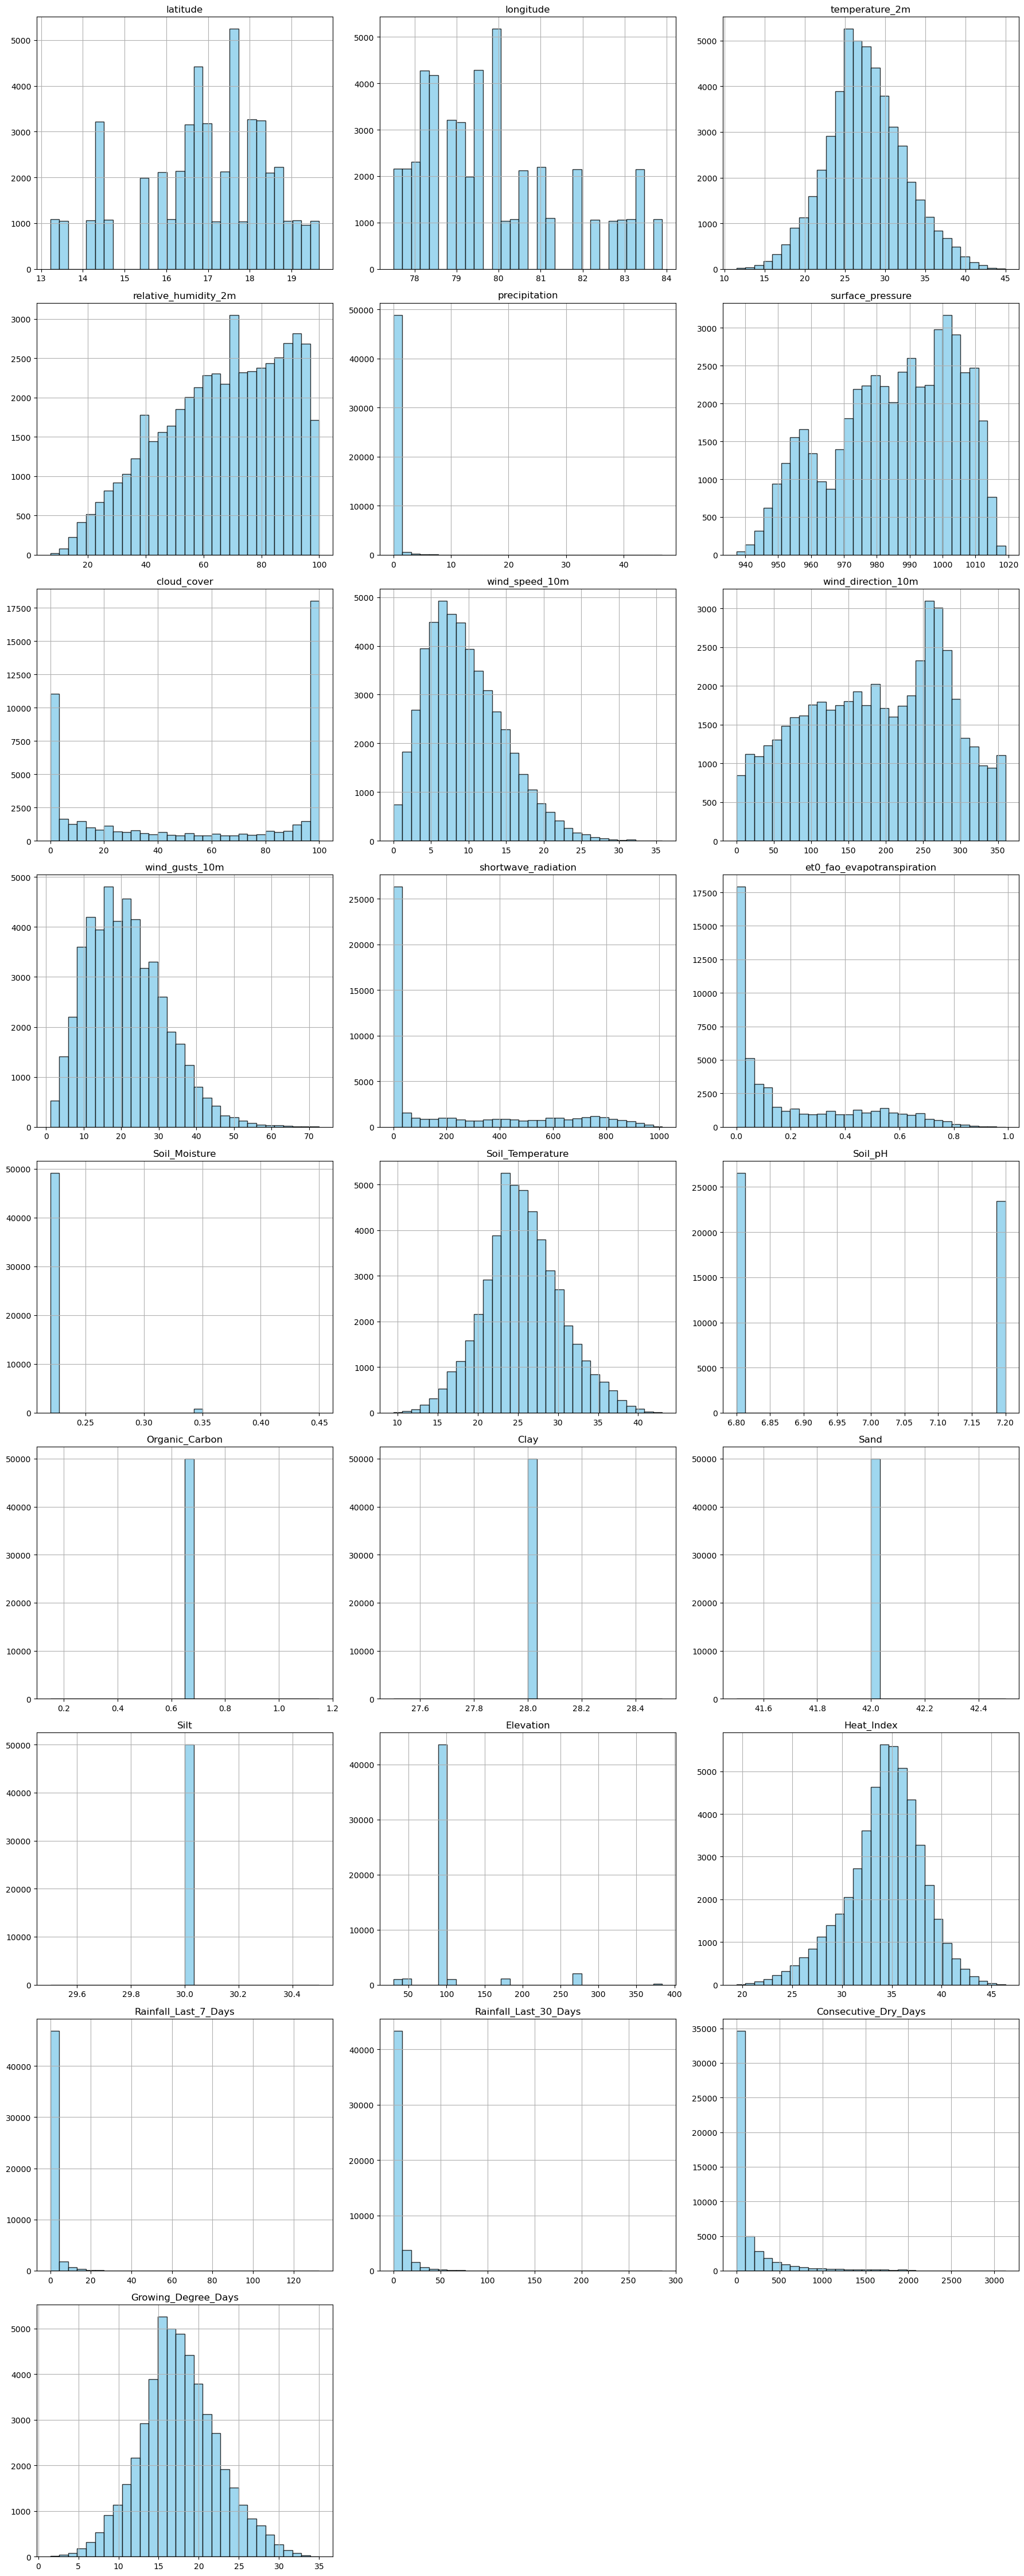

In [38]:
import matplotlib.pyplot as plt
# 1. Sample and select numeric columns
nums = df1.sample(n=50000, random_state=42).select_dtypes("number")
# 2. Pandas handles the looping, grid layout (-1 rows, 3 cols), and empty axes automatically!
nums.hist(
    bins=30, layout=(-1, 3), figsize=(18, 5 * ((len(nums.columns) + 2) // 3)), 
    color="skyblue", edgecolor="black", alpha=0.8
)
plt.tight_layout()
plt.show()

Business Insight: Temperature almost stabile with 26C to 35C temperature,humidity increase because present air water 99 percentage reach.rainfall very low,surface perssure fluctuations,cloud cover is completely cloud weather,wind speed reach almost high wind speed 6m/s. 

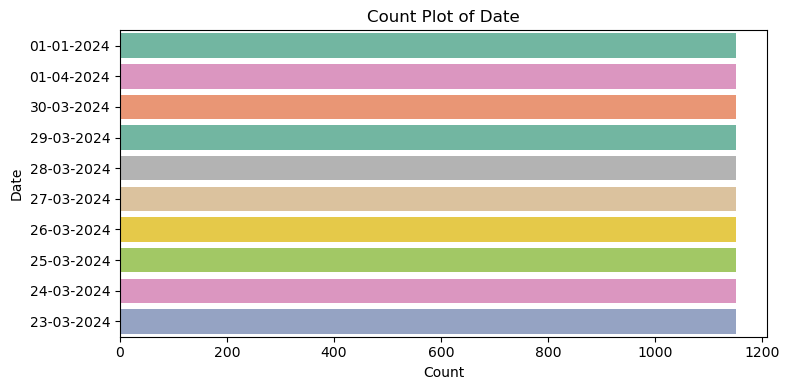

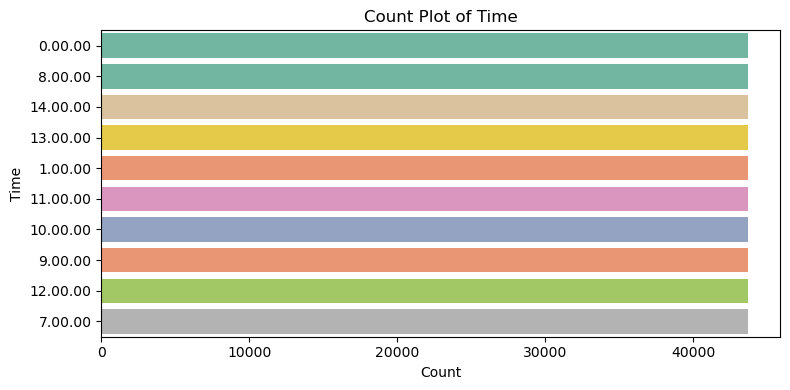

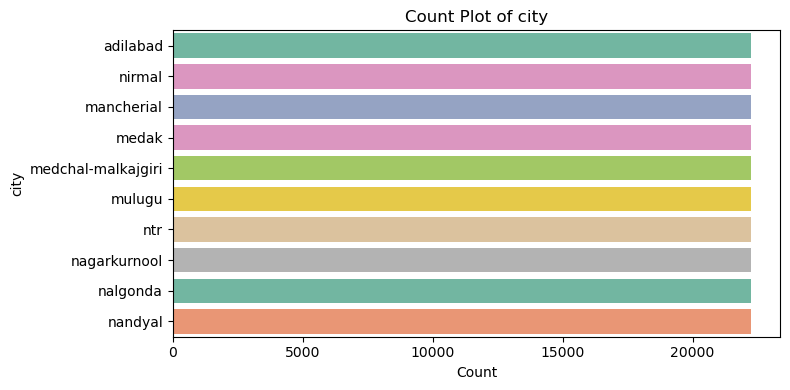

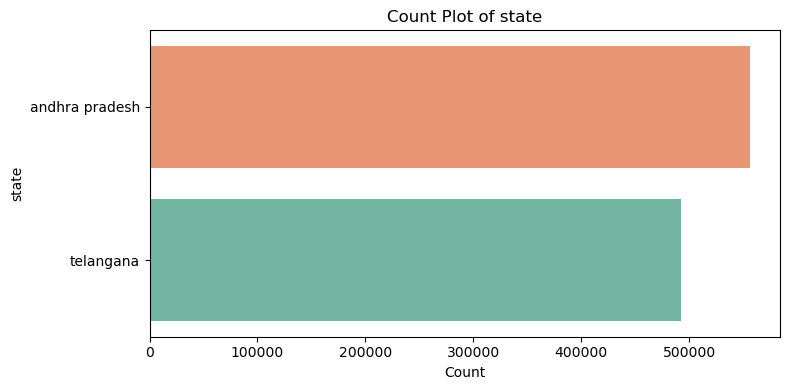

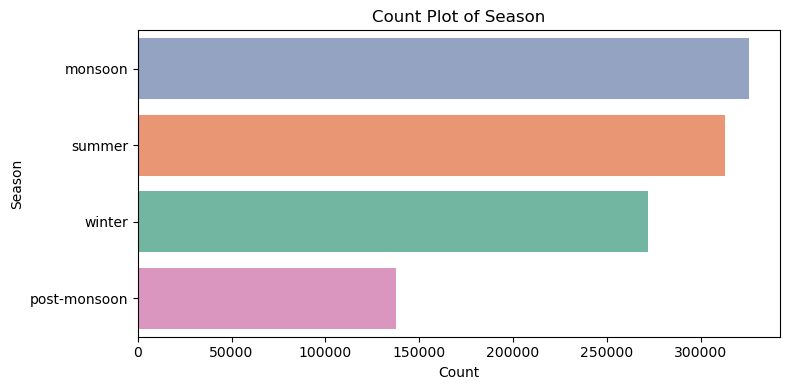

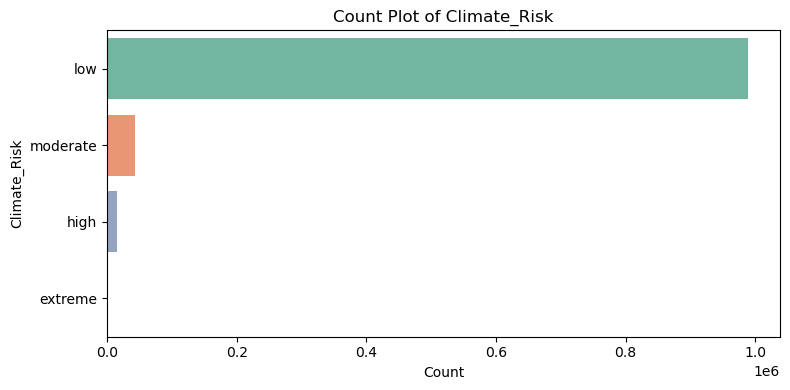

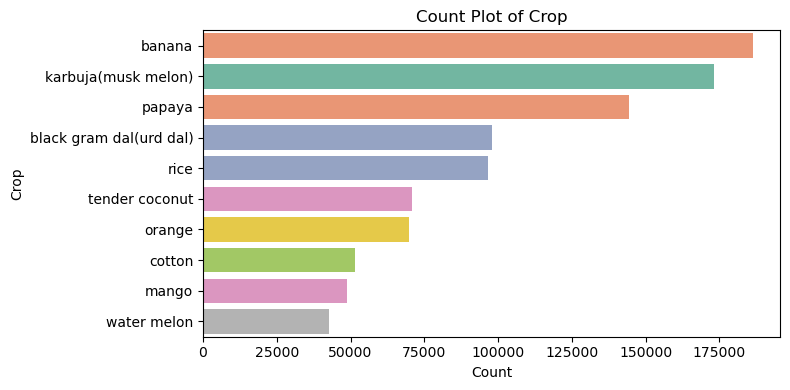

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
cat_columns = df1.select_dtypes(include=["object","category"]).columns
for col in cat_columns:
    plt.figure(figsize=(8,4))
    order = df1[col].value_counts().head(10).index
    sns.countplot(
    data=df1,
    y=col,
    order=order,
    hue=col,
    palette="Set2",
    legend=False
)
    plt.title(f"Count Plot of {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

business insights: city wise hanumakonda is highest in telangana.andhra pradesh is most of the crops monsoon time,summer,winter,post-monsoon,climate risk is low risky,most demand Banana,karbuja,papaya

##### Histogram visualiztion graphs.

Temperature,humidity,precipitation Distribution

##### Boxplots

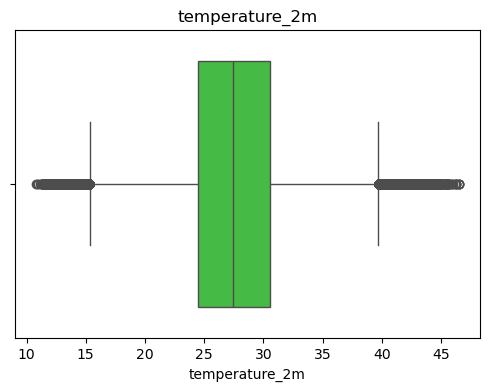

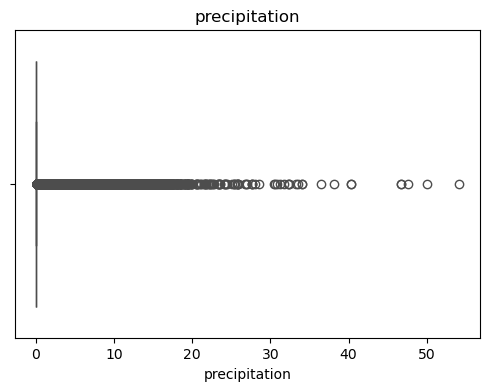

In [40]:
for col in ["temperature_2m", "precipitation"]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df1[col], color="limegreen").set(title=col)
    plt.show()

business insigts:based on bloxplot observation is temperature balancing in 24C to 32C daily fluctuations.rainfall is very low chance to risk crop.

### Bivariate Analysis

Bivariate analysis is a statistical method used to determine the relationship between exactly two variables

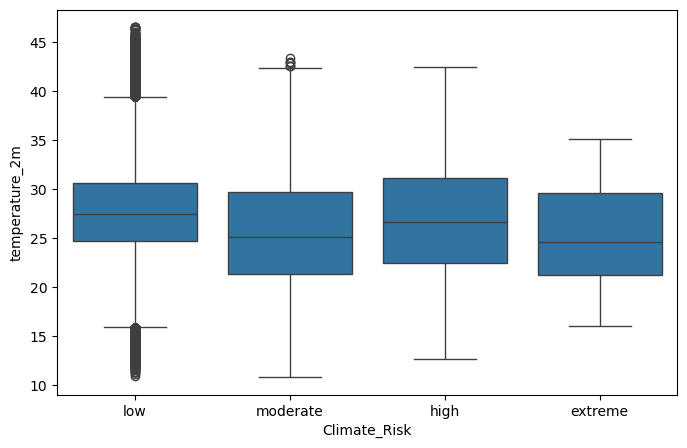

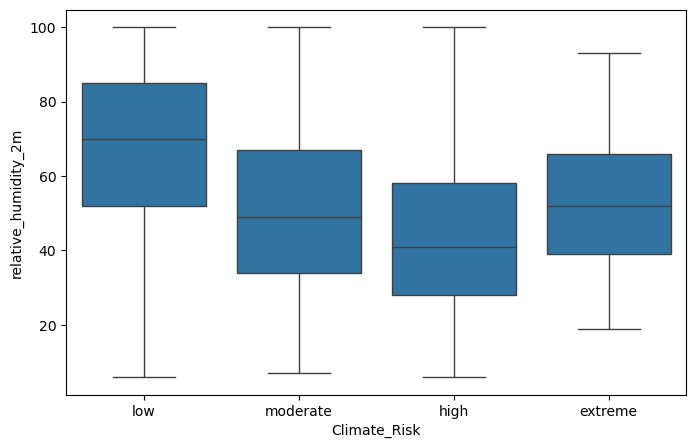

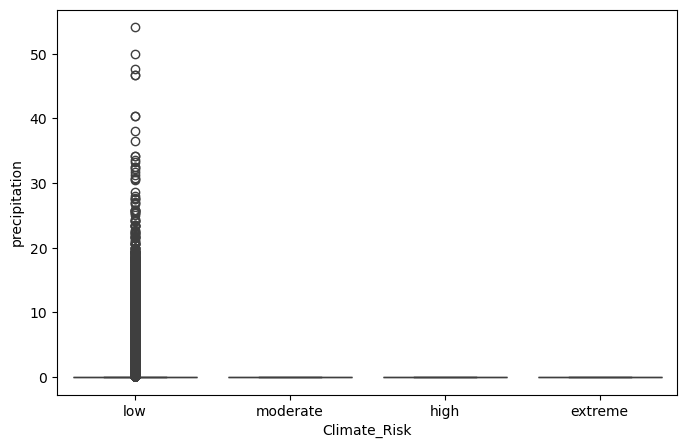

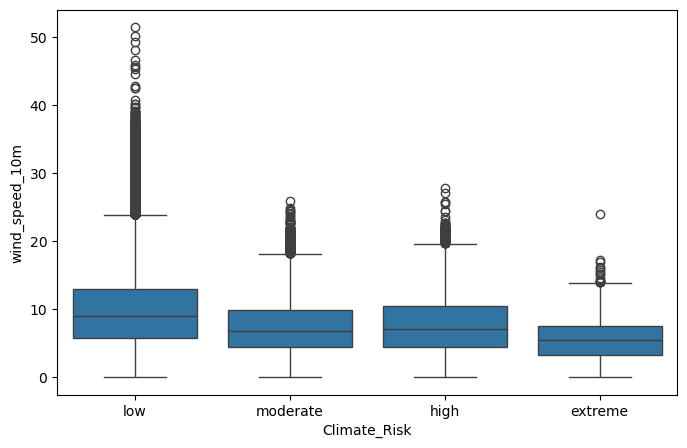

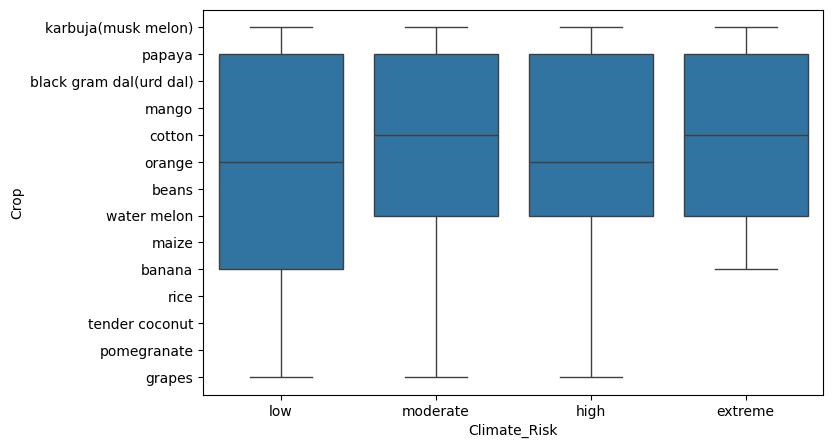

In [41]:
for col in "temperature_2m relative_humidity_2m precipitation wind_speed_10m Crop".split():
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df1, x="Climate_Risk", y=col)
    plt.show()

business insights:Climate risk categories show distinct weather patterns. High and extreme risk are associated with greater variability in temperature and wind speed, while precipitation is highly skewed, with most days recording no rainfall. These insights help improve climate risk forecasting, agricultural planning, irrigation scheduling, and disaster preparedness.

#### Categorical Analysis

State-wise Records

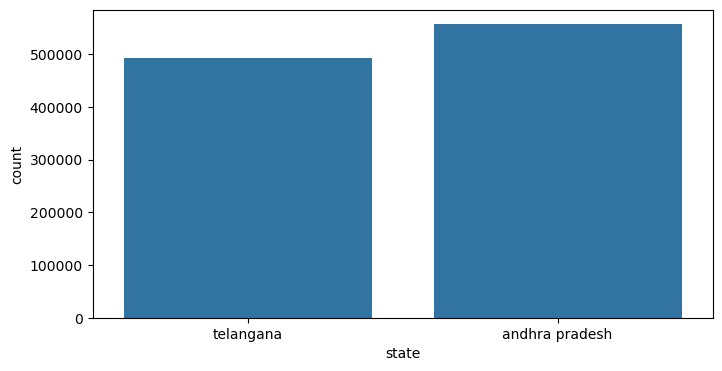

In [42]:
plt.figure(figsize=(8,4))
sns.countplot(x="state", data=df1)
plt.show()

Business Insights:Andhra Pradesh has more weather records than Telangana, indicating broader data coverage. This improves model reliability and supports more accurate climate risk analysis.

### Multivariate Analysis

Multivariate analysis is a statistical technique used to analyze datasets involving three or more variables simultaneously

##### Pair Plot

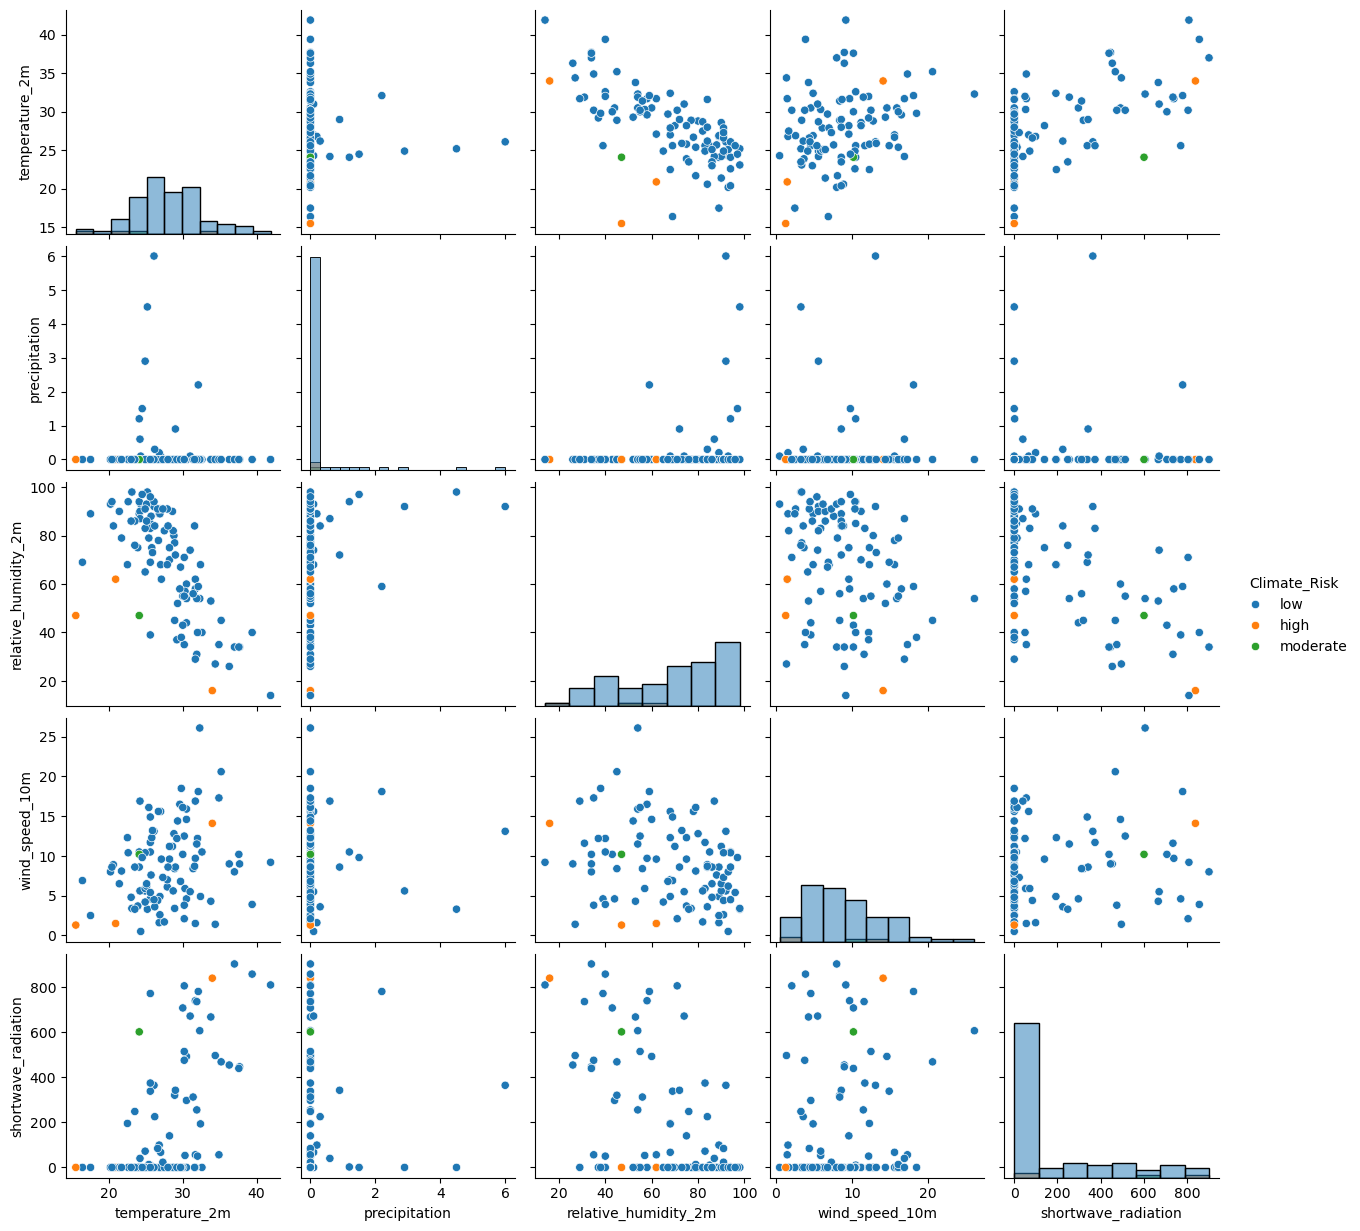

In [43]:
cols = "temperature_2m precipitation relative_humidity_2m wind_speed_10m shortwave_radiation Climate_Risk".split()
sns.pairplot(df1[cols].sample(100), hue="Climate_Risk", diag_kind="hist")
plt.show()

Business Insights:The pair plot indicates a strong negative relationship between temperature and humidity, while precipitation is concentrated near zero, showing infrequent rainfall events. Shortwave radiation increases with temperature, and wind speed shows moderate variability. These relationships improve climate risk prediction, irrigation planning, and weather-based agricultural decision-making.

##### Correlation Matrix

Correlation (corr) measures the strength and direction of the relationship between two numerical variables. It tells you whether two variables increase together, decrease together, or have no relationship.

In [44]:
corr = df1.select_dtypes(include="number").corr()
corr

,latitude,longitude,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,wind_gusts_10m,...,Organic_Carbon,Clay,Sand,Silt,Elevation,Heat_Index,Rainfall_Last_7_Days,Rainfall_Last_30_Days,Consecutive_Dry_Days,Growing_Degree_Days
latitude,1.000000,0.236060,-0.077994,0.014836,0.020722,-0.093026,-0.088763,-0.139831,0.083294,-0.143017,...,NaN,NaN,NaN,NaN,-0.077107,-0.091184,0.031990,0.045193,0.119557,-0.077994
longitude,0.236060,1.000000,0.021988,0.281315,0.037080,0.740146,0.002647,-0.080885,0.010800,-0.045683,...,NaN,NaN,NaN,NaN,-0.280825,0.186866,0.057246,0.080885,-0.139632,0.021988
temperature_2m,-0.077994,0.021988,1.000000,-0.657872,-0.051537,0.012493,0.035552,0.224860,0.090989,0.426775,...,NaN,NaN,NaN,NaN,0.015739,0.905131,-0.072188,-0.062489,-0.129136,1.000000
relative_humidity_2m,0.014836,0.281315,-0.657872,1.000000,0.174178,0.211851,0.300470,-0.114420,0.113016,-0.276686,...,NaN,NaN,NaN,NaN,-0.094496,-0.275280,0.257622,0.303322,-0.283405,-0.657872
precipitation,0.020722,0.037080,-0.051537,0.174178,1.000000,-0.012926,0.170633,0.068816,0.050019,0.100432,...,NaN,NaN,NaN,NaN,-0.013341,0.032535,0.582192,0.394141,-0.086385,-0.051537
surface_pressure,-0.093026,0.740146,0.012493,0.211851,-0.012926,1.000000,-0.089301,-0.115407,-0.106755,-0.089449,...,NaN,NaN,NaN,NaN,-0.143000,0.135535,-0.020642,-0.028270,-0.056415,0.012493
cloud_cover,-0.088763,0.002647,0.035552,0.300470,0.170633,-0.089301,1.000000,0.220421,0.233953,0.199690,...,NaN,NaN,NaN,NaN,-0.007012,0.214994,0.246023,0.321379,-0.334288,0.035552
wind_speed_10m,-0.139831,-0.080885,0.224860,-0.114420,0.068816,-0.115407,0.220421,1.000000,0.122808,0.891426,...,NaN,NaN,NaN,NaN,-0.008771,0.222443,0.077238,0.124865,-0.149140,0.224860
wind_direction_10m,0.083294,0.010800,0.090989,0.113016,0.050019,-0.106755,0.233953,0.122808,1.000000,0.104890,...,NaN,NaN,NaN,NaN,0.000026,0.179943,0.088690,0.127301,-0.152557,0.090989
wind_gusts_10m,-0.143017,-0.045683,0.426775,-0.276686,0.100432,-0.089449,0.199690,0.891426,0.104890,1.000000,...,NaN,NaN,NaN,NaN,-0.008235,0.388589,0.080065,0.113005,-0.141804,0.426775


Business Insights:Correlation analysis shows temperature is strongly associated with Heat Index (0.91), ET₀ (0.72), and solar radiation (0.63), while negatively related to humidity (-0.66). Soil moisture strongly depends on precipitation (0.84). These relationships improve climate risk prediction, irrigation planning, and crop management decisions.


### Average Weather by Climate Risk

In [45]:
df1.groupby("Climate_Risk")[[
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    'cloud_cover',
    'wind_speed_10m'
]].mean()

,temperature_2m,relative_humidity_2m,precipitation,cloud_cover,wind_speed_10m
Climate_Risk,,,,,
extreme,25.241044,52.622183,0.000000,14.211151,5.571649
high,26.830246,44.027054,0.000000,16.814870,7.660646
low,27.703687,67.130274,0.136489,57.109187,9.716570
moderate,25.424788,51.447067,0.000000,19.207281,7.384149


Business Insights:Low-risk conditions have higher humidity (67%), light rainfall and stronger winds. High-risk periods show lower humidity, no rainfall and warmer temperatures, increasing crop water stress.

### EDA Summary

Duplicate Rows: There are no duplicate records present.

Target Distribution: The target variable (Climate_Risk) is [Balanced / Imbalanced]. (Note: Check your specific count to confirm which applies).

Temperature: Exhibits a right-skewed distribution, indicating a cluster of lower/average temperatures with a tail of extreme heat events.

Precipitation: Contains a high frequency of zero values, which is typical for dry weather days.

Humidity: Relative humidity levels are predominantly moderate to high.

Wind Speed: Generally stable, though a few extreme high-speed values were recorded.

Correlation: There is a notable positive correlation between temperature and the Climate_Risk target.

Outliers: Genuine extreme weather outliers are present in both the precipitation and wind gust columns.

### Predictive Modeling

### Modeling Input X
Date
Time
city
state
latitude
longitude
temperature_2m
relative_humidity_2m
precipitation
surface_pressure
cloud_cover
wind_speed_10m
wind_direction_10m
wind_gusts_10m
shortwave_radiation
et0_fao_evapotranspiration
Season
Soil_Moisture
Soil_Temperature
Soil_pH
Organic_Carbon
Clay
Sand
Silt
Elevation
Heat_Index
Rainfall_Last_7_Days
Rainfall_Last_30_Days
Consecutive_Dry_Days
Growing_Degree_Days
Crop
### Y Predict
Climate_Risk

##### Pre-Requisites

Missing Values Identification

In [46]:
print(df1.isna().sum())

Date                          0
Time                          0
city                          0
state                         0
latitude                      0
longitude                     0
temperature_2m                0
relative_humidity_2m          0
precipitation                 0
surface_pressure              0
cloud_cover                   0
wind_speed_10m                0
wind_direction_10m            0
wind_gusts_10m                0
shortwave_radiation           0
et0_fao_evapotranspiration    0
Season                        0
Soil_Moisture                 0
Soil_Temperature              0
Soil_pH                       0
Organic_Carbon                0
Clay                          0
Sand                          0
Silt                          0
Elevation                     0
Heat_Index                    0
Rainfall_Last_7_Days          0
Rainfall_Last_30_Days         0
Consecutive_Dry_Days          0
Growing_Degree_Days           0
Climate_Risk                  0
Crop    

In [47]:
print(df1.duplicated().sum())

0


In [48]:
print(df1.head())
print(df1.columns)
print(df1.shape)

         Date     Time      city      state  latitude  longitude  \
0  01-01-2024  0.00.00  adilabad  telangana   19.6641     78.532   
1  01-01-2024  1.00.00  adilabad  telangana   19.6641     78.532   
2  01-01-2024  2.00.00  adilabad  telangana   19.6641     78.532   
3  01-01-2024  3.00.00  adilabad  telangana   19.6641     78.532   
4  01-01-2024  4.00.00  adilabad  telangana   19.6641     78.532   

   temperature_2m  relative_humidity_2m  precipitation  surface_pressure  ...  \
0            18.4                    80            0.0             983.7  ...   
1            17.8                    79            0.0             983.5  ...   
2            17.6                    77            0.0             983.3  ...   
3            16.9                    78            0.0             983.0  ...   
4            16.8                    79            0.0             983.3  ...   

   Sand  Silt  Elevation  Heat_Index  Rainfall_Last_7_Days  \
0    42    30        100        26.4      

In [49]:
# Temperature
print("temperature_min: ",df1["temperature_2m"].min())
print("temperature_max: ",df1["temperature_2m"].max())
# Rainfall
print("precipitation_min: ",df1["precipitation"].min())
print("precipitation_max: ",df1["precipitation"].max())
# Humidity
print("humidity_min: ",df1["relative_humidity_2m"].min())
print("humidity_max: ",df1["relative_humidity_2m"].max())
# Wind Speed
print("wind_speed_min: ",df1["wind_speed_10m"].min())
print("wind_speed_max: ",df1["wind_speed_10m"].max())

temperature_min:  10.8
temperature_max:  46.5
precipitation_min:  0.0
precipitation_max:  54.1
humidity_min:  6
humidity_max:  100
wind_speed_min:  0.0
wind_speed_max:  51.5


### Feature Engineering

Feature engineering is the process of using domain knowledge to extract and transform raw data into meaningful variables. This vital step directly improves the accuracy of machine learning algorithms.

### ordinal encoding

**Ordinal Encoding** is a categorical data preprocessing technique that converts ordered categorical values into numerical labels while preserving their natural ranking. Each category is assigned an integer based on its order (e.g., Low = 0, Medium = 1, High = 2, Extreme = 3). It is suitable for machine learning models when categories have a meaningful sequence. Ordinal encoding improves model compatibility with numerical algorithms while maintaining the relative importance of the categories.


In [50]:
risk_mapping = {
    "low": 0,
    "moderate": 1,
    "high": 2,
    "extreme": 3
}
df1["Climate_Risk_Ordinal"] = df1["Climate_Risk"].map(risk_mapping)
risk_mapping

{'low': 0, 'moderate': 1, 'high': 2, 'extreme': 3}

In [51]:
print(df1.columns.tolist())

['Date', 'Time', 'city', 'state', 'latitude', 'longitude', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'surface_pressure', 'cloud_cover', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'shortwave_radiation', 'et0_fao_evapotranspiration', 'Season', 'Soil_Moisture', 'Soil_Temperature', 'Soil_pH', 'Organic_Carbon', 'Clay', 'Sand', 'Silt', 'Elevation', 'Heat_Index', 'Rainfall_Last_7_Days', 'Rainfall_Last_30_Days', 'Consecutive_Dry_Days', 'Growing_Degree_Days', 'Climate_Risk', 'Crop', 'Climate_Risk_Ordinal']


### Train/Test Split — Classification Setup
Rebuilds X (features) and y (Climate_Risk) from df1 and performs a stratified train/test split.

In [52]:
from sklearn.model_selection import train_test_split
# Rebuild X (unencoded) from scratch
feature_cols = [
    "city", "state", "latitude", "longitude",
    "temperature_2m", "relative_humidity_2m", "precipitation",
    "surface_pressure", "cloud_cover", "wind_speed_10m",
    "wind_direction_10m", "wind_gusts_10m", "shortwave_radiation",
    "et0_fao_evapotranspiration", "Season", "Soil_Moisture",
    "Soil_Temperature", "Soil_pH", "Organic_Carbon", "Clay", "Sand",
    "Silt", "Elevation", "Heat_Index", "Rainfall_Last_7_Days",
    "Rainfall_Last_30_Days", "Consecutive_Dry_Days",
    "Growing_Degree_Days", "Crop"
]
X = df1[feature_cols].copy()
y = df1["Climate_Risk"].copy()

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [54]:
print(X_train.columns.tolist())

['city', 'state', 'latitude', 'longitude', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'surface_pressure', 'cloud_cover', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'shortwave_radiation', 'et0_fao_evapotranspiration', 'Season', 'Soil_Moisture', 'Soil_Temperature', 'Soil_pH', 'Organic_Carbon', 'Clay', 'Sand', 'Silt', 'Elevation', 'Heat_Index', 'Rainfall_Last_7_Days', 'Rainfall_Last_30_Days', 'Consecutive_Dry_Days', 'Growing_Degree_Days', 'Crop']


### One-Hot Encoding
Encodes city/state/Crop/Season as one-hot columns instead of label-encoded integers. Fit only on X_train, transformed onto X_test, to avoid data leakage.

In [55]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import joblib
# Columns to One-Hot Encode
one_hot_cols = ['city', "state", "Crop", "Season"]   # match actual column names/casing
for col in one_hot_cols:
    if col not in X_train.columns:
        raise ValueError(f"Column '{col}' not found in X_train! Check spelling/casing.")
encoders = {}
for col in one_hot_cols:
    # Create encoder
    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    # Fit on training data
    train_encoded = encoder.fit_transform(X_train[[col]])
    # Transform test data
    test_encoded = encoder.transform(X_test[[col]])
    # Convert to DataFrames
    train_df = pd.DataFrame(
        train_encoded,
        columns=encoder.get_feature_names_out([col]),
        index=X_train.index
    ).astype(int)
    test_df = pd.DataFrame(
        test_encoded,
        columns=encoder.get_feature_names_out([col]),
        index=X_test.index
    ).astype(int)
    # Remove original column and add encoded columns
    X_train = pd.concat([X_train.drop(columns=[col]), train_df], axis=1)
    X_test = pd.concat([X_test.drop(columns=[col]), test_df], axis=1)
    # Save encoder
    encoders[col] = encoder
    joblib.dump(encoders, "onehot_encoders.pkl")
print("All encoders saved successfully!")

All encoders saved successfully!


### Model Training

### Full Classification Pipeline — Compare All Algorithms Classification Models
Trains Logistic Regression, KNN, SVC, Decision Tree, Random Forest, and XGBoost side by side and compares them using Test Accuracy and Test Macro F1 (the metric that matters given the class imbalance).

In [56]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

Model Training Process

In [61]:
s_idx = X_train.sample(2000, random_state=42).index
Xs, ys = X_train.loc[s_idx], y_train.loc[s_idx]

models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, class_weight="balanced"), X_train, y_train),
    "KNN": (KNeighborsClassifier(n_jobs=-1), Xs, ys),
    "SVC": (SVC(class_weight="balanced"), Xs, ys),
    "Decision Tree": (DecisionTreeClassifier(max_depth=6, min_samples_leaf=50, class_weight="balanced", random_state=42), X_train, y_train),
    "Random Forest": (RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=50, class_weight="balanced", random_state=42, n_jobs=-1), X_train, y_train)
}

results = []
for name, (model, X_tr, y_tr) in models.items():
    print(f"Training {name}...")
    model.fit(X_tr, y_tr)
    tr_pred, te_pred = model.predict(X_tr), model.predict(X_test)
    tr_acc, te_acc = accuracy_score(y_tr, tr_pred), accuracy_score(y_test, te_pred)
    fit_status = "Underfit" if (tr_acc < 0.5 and te_acc < 0.5) else "Overfit" if abs(tr_acc - te_acc) > 0.20 else "Good Fit"
    results.append({
        "Model": name,
        "Train Accuracy": tr_acc,
        "Test Accuracy": te_acc,
        "Train Macro F1": f1_score(y_tr, tr_pred, average="macro"),
        "Test Macro F1": f1_score(y_test, te_pred, average="macro"),
        "Fit": fit_status
    })

# Build the table
results_df = pd.DataFrame(results)
results_df

TypeError: cannot unpack non-iterable LogisticRegression object

In [58]:
# Prediction
y_pred = model.predict(X_test)
print(y_pred)

['moderate' 'low' 'low' ... 'low' 'low' 'high']


In [59]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8662661230717879

Classification Report:
              precision    recall  f1-score   support

     extreme       0.19      1.00      0.33       337
        high       0.19      0.87      0.32      2964
         low       1.00      0.86      0.93    197744
    moderate       0.33      0.91      0.49      8670

    accuracy                           0.87    209715
   macro avg       0.43      0.91      0.51    209715
weighted avg       0.96      0.87      0.90    209715


Confusion Matrix:
[[   337      0      0      0]
 [   110   2583      0    271]
 [  1069  10187 170850  15638]
 [   217    509     45   7899]]


In [60]:
import joblib
# Save trained model
with open("climate_risk_model.pkl", "wb") as file:
    joblib.dump(model, file)
print("Model saved successfully!")

Model saved successfully!
